# Multichannel Tryout for 488

In [6]:
from __future__ import annotations
import time
import tkinter
import pathlib
import pickle
import tifffile
import os
import numpy as np
from PIL import (Image, ImageTk, ImageDraw)
from tkinter import filedialog, messagebox
from matplotlib.figure import Figure 
from matplotlib.backends.backend_tkagg import (FigureCanvasTkAgg, NavigationToolbar2Tk)
from matplotlib.patches import Rectangle, Circle
from matplotlib.backend_bases import MouseEvent
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import matplotlib.pyplot as plt
from skimage import measure
import fishCore
import fishGUI
import threading
import concurrent.futures
import cv2
import imageio.v3 as iio
import napari
from aicsimageio import AICSImage

f = fishCore.Fish(pathlib.Path("./config.ini"))
f.set_model_version("3.50")

c:\Users\msgal\Downloads\Ding_Lab\FISH-ML\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


final text_encoder_type: bert-base-uncased


[2025-08-26 17:52:59,807][INFO] CHECK: Model version 3.50 loaded


In [7]:
def helper__hdr2Rgb(hdr_image: np.ndarray, dynamic_range: int) -> np.ndarray:
        scale_factor = 255 / dynamic_range # 65536
        scaled_image = (hdr_image * scale_factor).astype(np.uint8)
        rgb_image = np.stack((scaled_image,) * 3, axis=-1)
        return rgb_image

def helper__hdr2RgbNorm(hdr_image: np.ndarray, brightness_factor: int) -> np.ndarray:
        img_normalized = cv2.normalize(hdr_image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        img_rgb = cv2.cvtColor(img_normalized, cv2.COLOR_GRAY2RGB)
        return np.clip(img_rgb * brightness_factor, 0, 255).astype(np.uint8)

### Displaying Separate Nucleus and Cytoplasm Files

Cyt shape: (2048, 2048)
Nuc shape: (2048, 2048)


(-0.5, 2047.5, 2047.5, -0.5)

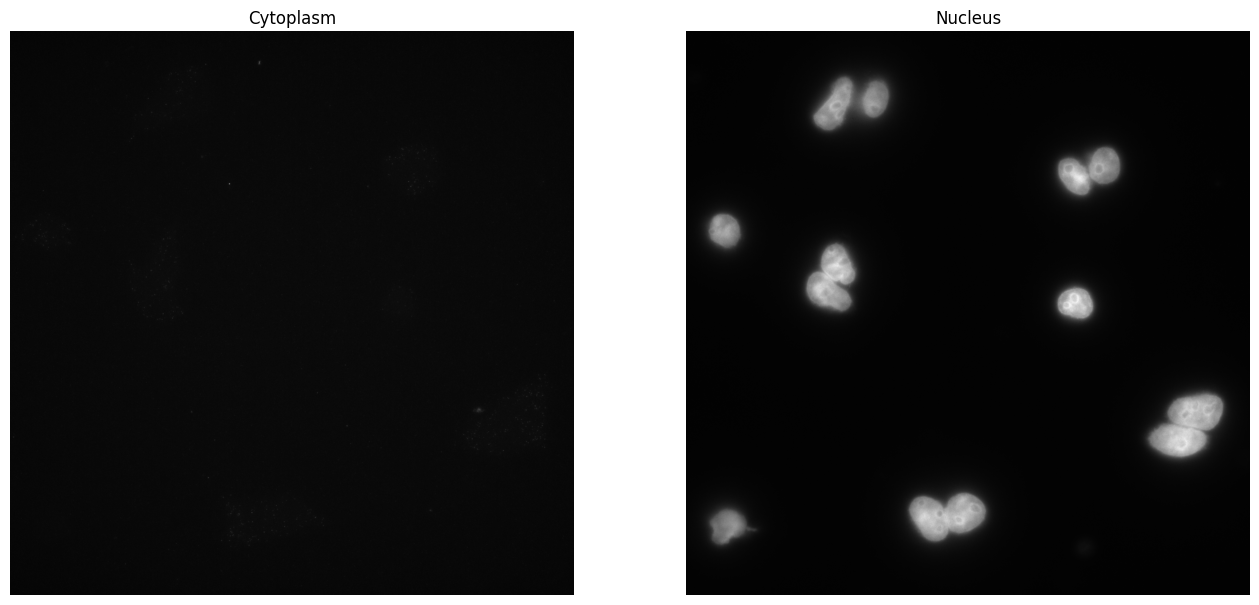

In [1]:
import tifffile
import matplotlib.pyplot as plt

cyt_path = "C:/Users/msgal/Downloads/Ding_Lab/FISH-ML/data_vadym_singletif_STACKED/MAX_EXP_w488_s0026.tif"
nuc_path = "C:/Users/msgal/Downloads/Ding_Lab/FISH-ML/data_vadym_singletif_STACKED/MAX_EXP_wDAPI_s0026.tif"

cyt_img = tifffile.imread(cyt_path)
nuc_img = tifffile.imread(nuc_path)

print(f"Cyt shape: {cyt_img.shape}")
print(f"Nuc shape: {cyt_img.shape}")

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 10), sharex=True, sharey=True)

ax[0].imshow(cyt_img, cmap='gray')
ax[0].set_title("Cytoplasm")
ax[0].axis('off')

ax[1].imshow(nuc_img, cmap='gray')
ax[1].set_title("Nucleus")
ax[1].axis('off')


## Adaptive Noise Removal (No Outlier Removal)

Estimated Gaussian noise standard deviation = 1.9212288361703882
Estimated Gaussian noise standard deviation = 9.124409860064004


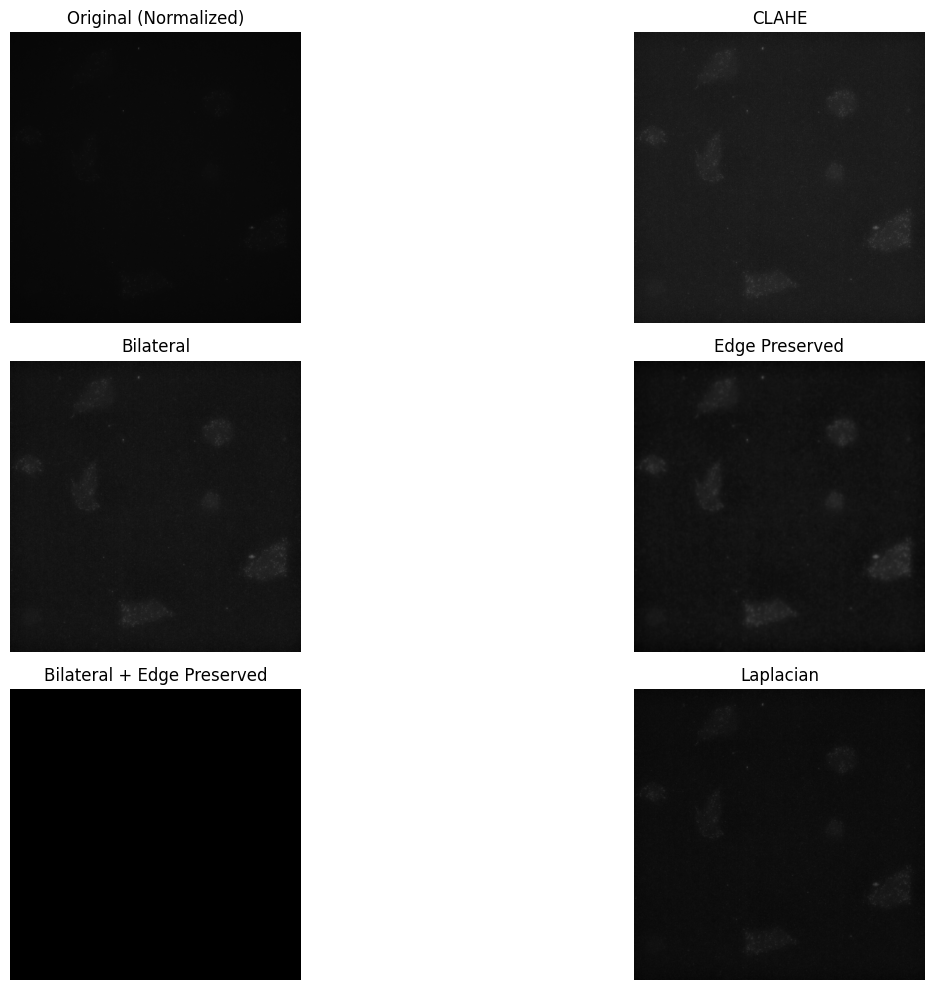

In [3]:
import cv2
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from skimage import filters, morphology, measure, segmentation
from scipy import ndimage as ndi
import pathlib
from skimage.restoration import (
    denoise_tv_chambolle,
    denoise_bilateral,
    denoise_wavelet,
    estimate_sigma,
)

# --------------------------------------
# Helper functions
# --------------------------------------

def normalize_to_uint8(img):
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def calculate_sigma(img):
    # ----- ESTIMATE SIGMA - Due to clipping in random_noise, the estimate will be a bit smaller than the specified sigma.
    print(f'Estimated Gaussian noise standard deviation = {estimate_sigma(img)}')
    sig = estimate_sigma(img, channel_axis=-1, average_sigmas=True)
    return sig
    
def clahe(img, clip_limit=4.0, tile_size=(8,8)):
    c = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    return c.apply(img)

def gradient(channel, ksize=5):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
    return cv2.morphologyEx(channel, cv2.MORPH_GRADIENT, kernel)

# --------------------------------------
# Load image and preprocess
# --------------------------------------

# ----- COMPOSITE IMAGES -----
# image_path = pathlib.Path("C:/Users/msgal/Downloads/Ding_Lab/FISH-ML/Composite Images (Multi-Channel)/488_pb5sp4_s1.composite.tif")

# with tifffile.TiffFile(image_path) as tif:
#     cyt = tif.pages[0].asarray() # testing with 488
#     nucleus = tif.pages[1].asarray()

# ----- NON COMPOSITE IMAGES -----
cyt_path = "C:/Users/msgal/Downloads/Ding_Lab/FISH-ML/data_vadym_singletif_STACKED/MAX_EXP_w488_s0026.tif"
nuc_path = "C:/Users/msgal/Downloads/Ding_Lab/FISH-ML/data_vadym_singletif_STACKED/MAX_EXP_wDAPI_s0026.tif"

with tifffile.TiffFile(cyt_path) as tif:
    cyt = tif.pages[0].asarray() # testing with 488

with tifffile.TiffFile(nuc_path) as tif:
    nucleus = tif.pages[0].asarray()

ch = normalize_to_uint8(cyt)

# ESTIMATE SIGMA - Due to clipping in random_noise, the estimate will be a bit smaller than the specified sigma.
sigma_est = estimate_sigma(ch, channel_axis=-1, average_sigmas=True)
print(f'Estimated Gaussian noise standard deviation = {sigma_est}')

clahe = clahe(ch)
grad = gradient(clahe)

# ESTIMATE SIGMA - Due to clipping in random_noise, the estimate will be a bit smaller than the specified sigma.
sigma_est = estimate_sigma(clahe, channel_axis=-1, average_sigmas=True)
print(f'Estimated Gaussian noise standard deviation = {sigma_est}')

sigma_norm = sigma_est + 3.0
sigma_weak = sigma_est - 10.0

bilat1 = cv2.bilateralFilter(clahe, d=9, sigmaColor=sigma_norm, sigmaSpace=15, borderType=cv2.BORDER_REFLECT_101)
edge_preserved = cv2.edgePreservingFilter(clahe, flags=1, sigma_s=sigma_norm, sigma_r=0.4)

bilat_edge = cv2.edgePreservingFilter(bilat1, flags=1, sigma_s=sigma_weak, sigma_r=0.4)

laplacian = cv2.Laplacian(ch, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)
blended = cv2.addWeighted(bilat1, 0.7, laplacian, 0.3, 0)

# --------------------------------------
# Visualization
# --------------------------------------
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(16, 10), sharex=True, sharey=True)

ax[0, 0].imshow(ch, cmap='gray')
ax[0, 0].set_title("Original (Normalized)")
ax[0, 0].axis('off')

ax[0, 1].imshow(clahe, cmap='gray')
ax[0, 1].set_title("CLAHE")
ax[0, 1].axis('off')


ax[1, 0].imshow(bilat1, cmap='gray')
ax[1, 0].set_title("Bilateral")
ax[1, 0].axis('off')

ax[1, 1].imshow(edge_preserved, cmap='gray')
ax[1, 1].set_title("Edge Preserved")
ax[1, 1].axis('off')

ax[2, 0].imshow(bilat_edge, cmap='gray')
ax[2, 0].set_title("Bilateral + Edge Preserved")
ax[2, 0].axis('off')

ax[2, 1].imshow(blended, cmap='gray')
ax[2, 1].set_title("Laplacian")
ax[2, 1].axis('off')


fig.tight_layout()

plt.show()

## Outlier Removing

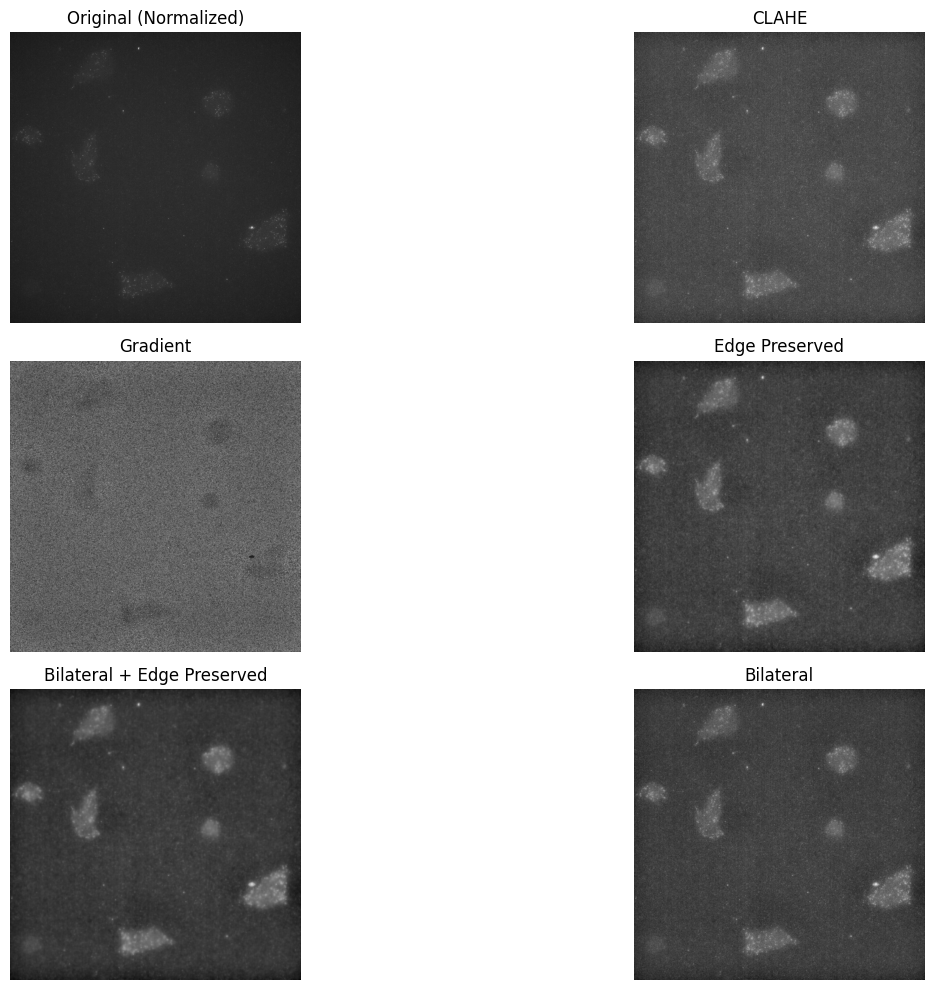

In [4]:
import cv2
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from skimage import filters, morphology, measure, segmentation
from scipy import ndimage as ndi
from math import log
from skimage import exposure
import pathlib
from skimage.restoration import (
    denoise_tv_chambolle,
    denoise_bilateral,
    denoise_wavelet,
    estimate_sigma,
)

# --------------------------------------
# Helper functions
# --------------------------------------
def remove_outliers(img, k=20.0, use_median=False):
    """
    Clip values that are more than k std-dev (or MAD units) above center.
    Args:
        img: 16-bit numpy array
        k: threshold (e.g. 3σ)
        use_median: if True use median+MAD, else mean+std
    Returns:
        clipped float32 image in [0,1]
    """
    x = img.astype(np.float32)

    mean = np.mean(x)
    std = np.std(x)
    thresh = mean + k * std

    # clip outliers
    x_clipped = np.minimum(x, thresh)

    # normalize after clipping (to 0..1)
    x_norm = (x_clipped - x_clipped.min()) / (x_clipped.max() - x_clipped.min() + 1e-6)
    return x_norm

def normalize_to_uint8(img):
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def calculate_sigma(img):
    # ----- ESTIMATE SIGMA - Due to clipping in random_noise, the estimate will be a bit smaller than the specified sigma.
    print(f'Estimated Gaussian noise standard deviation = {estimate_sigma(img)}')
    sig = estimate_sigma(img, channel_axis=None, average_sigmas=True)
    return sig

def apply_clahe(img, clip_limit=4.0, tile_size=(8,8)):
    c = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    return c.apply(img)

def laplacian(img, cyt_bilat):
    lap = cv2.Laplacian(img, cv2.CV_64F)
    lap = cv2.convertScaleAbs(lap)
    cyt_blended = cv2.addWeighted(cyt_bilat, 0.8, lap, 0.2, 0)
    return cyt_blended

def gradient(channel, ksize=5):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
    return cv2.morphologyEx(channel, cv2.MORPH_GRADIENT, kernel)

# --------------------------------------
# Load image and preprocess
# --------------------------------------

# ----- COMPOSITE IMAGES -----
# image_path = pathlib.Path("C:/Users/msgal/Downloads/Ding_Lab/FISH-ML/Composite Images (Multi-Channel)/488_pb5sp4_s1.composite.tif")

# with tifffile.TiffFile(image_path) as tif:
#     cyt = tif.pages[0].asarray() # testing with 488
#     nucleus = tif.pages[1].asarray()

# ----- NON COMPOSITE IMAGES -----
cyt_path = "C:/Users/msgal/Downloads/Ding_Lab/FISH-ML/data_vadym_singletif_STACKED/MAX_EXP_w488_s0026.tif"
nuc_path = "C:/Users/msgal/Downloads/Ding_Lab/FISH-ML/data_vadym_singletif_STACKED/MAX_EXP_wDAPI_s0026.tif" 

with tifffile.TiffFile(cyt_path) as tif:
    cyt = tif.pages[0].asarray() # testing with 488

with tifffile.TiffFile(nuc_path) as tif:
    nucleus = tif.pages[0].asarray()

cyt_removed = remove_outliers(cyt)
cyt_norm = normalize_to_uint8(cyt_removed)

sigma_est = estimate_sigma(cyt_norm, channel_axis=-1, average_sigmas=True)
clahe = apply_clahe(cyt_norm)
grad = gradient(clahe)
# gaussian = cv2.GaussianBlur(clahe, (0,0), 1.0)   

# contrast_factor = 1.5  # Greater than 1 for increased contrast
# brightness_offset = 1   # Adjust brightness (optional)
# enhanced = cv2.addWeighted(clahe, contrast_factor, np.zeros(clahe.shape, clahe.dtype), 0, brightness_offset)

sigma_est = estimate_sigma(clahe, channel_axis=-1, average_sigmas=True)

sigma_norm = sigma_est + 3.0
sigma_weak = (sigma_est - 10.0) if (sigma_est - 10.0) > 0 else 0

bilat1 = cv2.bilateralFilter(clahe, d=9, sigmaColor=sigma_norm, sigmaSpace=15, borderType=cv2.BORDER_REFLECT_101)
edge_preserved = cv2.edgePreservingFilter(clahe, flags=1, sigma_s=sigma_norm, sigma_r=0.4)
bilat_edge = cv2.edgePreservingFilter(bilat1, flags=1, sigma_s=sigma_weak, sigma_r=0.4)
blended = laplacian(cyt_norm, bilat1)

# --------------------------------------
# Visualization
# --------------------------------------
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(16, 10), sharex=True, sharey=True)

ax[0, 0].imshow(cyt_norm, cmap='gray')
ax[0, 0].set_title("Original (Normalized)")
ax[0, 0].axis('off')

ax[0, 1].imshow(clahe, cmap='gray')
ax[0, 1].set_title("CLAHE")
ax[0, 1].axis('off')


ax[1, 0].imshow(grad, cmap='gray')
ax[1, 0].set_title("Gradient")
ax[1, 0].axis('off')

ax[1, 1].imshow(edge_preserved, cmap='gray')
ax[1, 1].set_title("Edge Preserved")
ax[1, 1].axis('off')

ax[2, 0].imshow(bilat_edge, cmap='gray')
ax[2, 0].set_title("Bilateral + Edge Preserved")
ax[2, 0].axis('off')

ax[2, 1].imshow(bilat1, cmap='gray')
ax[2, 1].set_title("Bilateral")
ax[2, 1].axis('off')

# ax[3, 0].imshow(blended, cmap='gray')
# ax[3, 0].set_title("Blended")
# ax[3, 0].axis('off')


fig.tight_layout()

plt.show()

## Testing w/ Filters + Watershed-Guided Sam

Estimated Gaussian noise standard deviation = 6.474383927865731
Estimated Gaussian noise standard deviation = 28.602100910567195


[CYTO] Starting prediction for 7 cells
[CYTO] Input image shape: (2048, 2048, 3), dtype: uint8
[CYTO] Using pre-formatted 3-channel image as RGB
[CYTO] Cell 0: box=[1630.0, 1241.0, 1957.0, 1555.0], point=[1793.5, 1398.0]
[CYTO] Cell 1: box=[34.0, 657.0, 234.0, 803.0], point=[134.0, 730.0]
[CYTO] Cell 2: box=[445.0, 115.0, 728.0, 366.0], point=[586.5, 240.5]
[CYTO] Cell 3: box=[1349.0, 396.0, 1581.0, 615.0], point=[1465.0, 505.5]
[CYTO] Cell 4: box=[1337.0, 903.0, 1484.0, 1070.0], point=[1410.5, 986.5]
[CYTO] Cell 5: box=[760.0, 1670.0, 1159.0, 1884.0], point=[959.5, 1777.0]
[CYTO] Cell 6: box=[428.0, 697.0, 634.0, 1066.0], point=[531.0, 881.5]
[CYTO] Completed segmentation for 7 cells


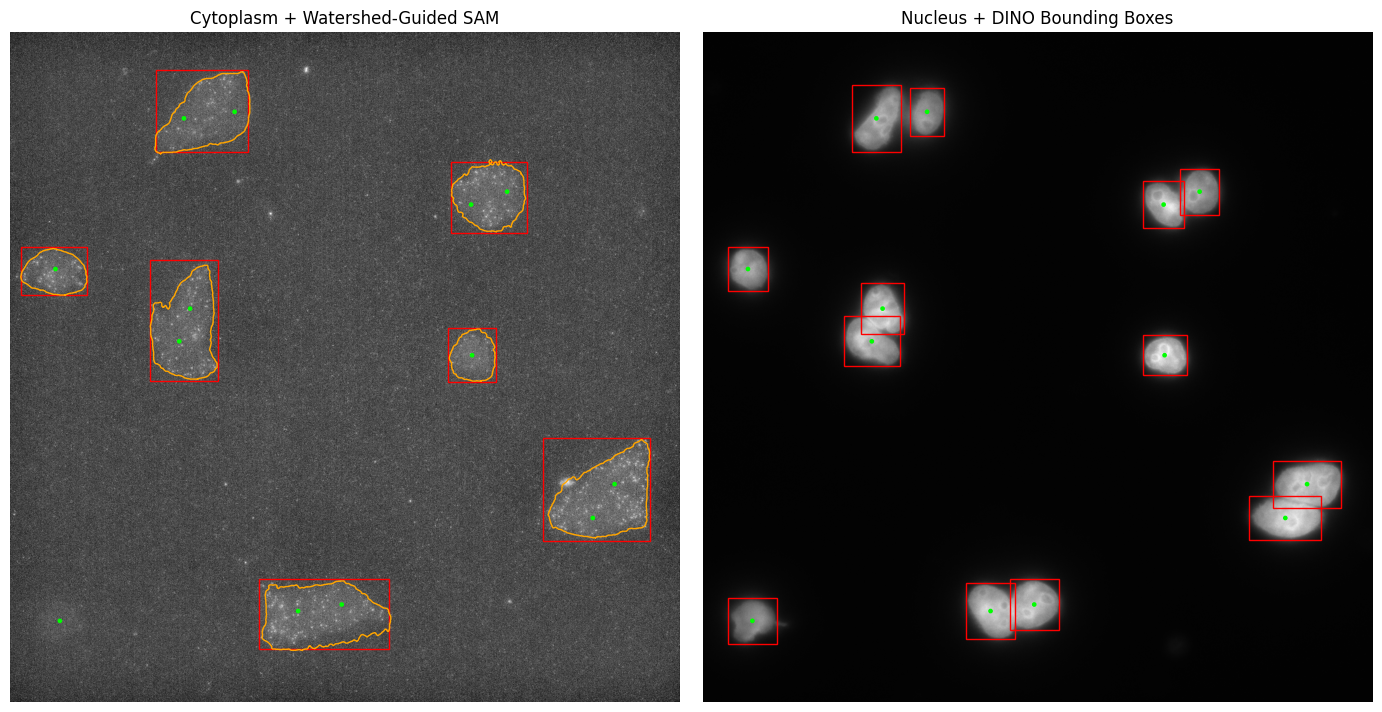

In [8]:
import cv2
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from skimage import filters, morphology, measure, segmentation
from scipy import ndimage as ndi
from skimage.restoration import (
    denoise_tv_chambolle,
    denoise_bilateral,
    denoise_wavelet,
    estimate_sigma,
)
import pathlib

# --------------------------------------
# Helper functions
# --------------------------------------
def remove_outliers(img, k=20.0, use_median=False):
    """
    Clip values that are more than k std-dev (or MAD units) above center.
    Args:
        img: 16-bit numpy array
        k: threshold (e.g. 3σ)
        use_median: if True use median+MAD, else mean+std
    Returns:
        clipped float32 image in [0,1]
    """
    x = img.astype(np.float32)

    if use_median:
        med = np.median(x)
        mad = np.median(np.abs(x - med)) + 1e-6
        sigma = 1.4826 * mad  # robust std estimate
        thresh = med + k * sigma
    else:
        mean = np.mean(x)
        std = np.std(x)
        thresh = mean + k * std

    # clip outliers
    x_clipped = np.minimum(x, thresh)

    # normalize after clipping (to 0..1)
    x_norm = (x_clipped - x_clipped.min()) / (x_clipped.max() - x_clipped.min() + 1e-6)
    return x_norm

def normalize_to_uint8(img):
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def calculate_sigma(img):
    # ----- ESTIMATE SIGMA - Due to clipping in random_noise, the estimate will be a bit smaller than the specified sigma.
    sig = estimate_sigma(img, channel_axis=None, average_sigmas=True)
    print(f'Estimated Gaussian noise standard deviation = {sig}')
    return sig

def clahe_filter(img, clip_limit=4.0, tile_size=(8,8)):
    c = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    return c.apply(img)

def laplacian(img, cyt_bilat):
    lap = cv2.Laplacian(img, cv2.CV_64F)
    lap = cv2.convertScaleAbs(lap)
    cyt_blended = cv2.addWeighted(cyt_bilat, 0.8, lap, 0.2, 0)
    return cyt_blended

def brightness(img, target_mean=70):
    mean_val = np.mean(img)

    # Compute needed offset (positive = brighten, negative = darken)
    offset = target_mean - mean_val
    # Build a constant image for addition
    adjustment = np.full(img.shape, offset, dtype=np.uint8) if offset > 0 else np.zeros_like(img)
    # Use cv.add to brighten, cv.subtract to darken
    if offset > 0:
        print("Brightness increased")
        result = cv2.add(img, adjustment)
    else:
        print("Brightness remained the same")
        result = img

    return result

def postproc_mask(m):
    m = morphology.remove_small_objects(m.astype(bool), min_size=200)
    m = morphology.binary_closing(m, footprint=morphology.disk(3))
    m = morphology.binary_opening(m, footprint=morphology.disk(2))
    return m.astype(np.uint8)

def mask_to_bbox(mask):
    ys, xs = np.where(mask)
    if len(xs) == 0 or len(ys) == 0:
        return None
    return (xs.min(), ys.min(), xs.max(), ys.max())

def watershed_segment_with_centers(cyt_img, centers):
    thresh = filters.threshold_otsu(cyt_img)
    binary = cyt_img > thresh
    binary = morphology.remove_small_holes(binary, area_threshold=1000)
    # binary = morphology.remove_small_objects(binary, min_size=1000)
    dist = ndi.distance_transform_edt(binary)

    markers = np.zeros(cyt_img.shape, dtype=np.int32)
    for i, (cx, cy) in enumerate(centers, start=1):
        xi, yi = int(round(cx)), int(round(cy))
        if 0 <= yi < cyt_img.shape[0] and 0 <= xi < cyt_img.shape[1]:
            markers[yi, xi] = i

    edges = filters.sobel(cyt_img)
    elevation = -dist + 5 * edges
    labels = segmentation.watershed(elevation, markers=markers, mask=binary)

    masks = []
    for i in range(1, np.max(labels)+1):
        mask = (labels == i)
        if np.sum(mask) > 0:
            masks.append(postproc_mask(mask))
    return masks

# --------------------------------------
# Load image and preprocess
# --------------------------------------

# ----- COMPOSITE IMAGES -----
# image_path = pathlib.Path("C:/Users/msgal/Downloads/Ding_Lab/FISH-ML/Composite Images (Multi-Channel)/488_pb5sp4_s1.composite.tif")

# with tifffile.TiffFile(image_path) as tif:
#     cyt = tif.pages[0].asarray() # testing with 488
#     nucleus = tif.pages[1].asarray()

# ----- NON COMPOSITE IMAGES -----
cyt_path = "C:/Users/msgal/Downloads/Ding_Lab/FISH-ML/data_vadym_singletif_STACKED/MAX_EXP_w488_s0026.tif"
nuc_path = "C:/Users/msgal/Downloads/Ding_Lab/FISH-ML/data_vadym_singletif_STACKED/MAX_EXP_wDAPI_s0026.tif" 

with tifffile.TiffFile(cyt_path) as tif:
    cyt = tif.pages[0].asarray() # testing with 488

with tifffile.TiffFile(nuc_path) as tif:
    nucleus = tif.pages[0].asarray()

cyt_removed = remove_outliers(cyt)
cyt_norm = normalize_to_uint8(cyt_removed)

sigma_est = calculate_sigma(cyt) # Calculate sigma

cyt_clahe = clahe_filter(cyt_norm) 

sigma_est = calculate_sigma(cyt_clahe)
sigma_norm = sigma_est + 3.0
sigma_weak = sigma_est - 10.0

cyt_bilat = cv2.bilateralFilter(cyt_clahe, d=9, sigmaColor=sigma_norm, sigmaSpace=15, borderType=cv2.BORDER_REFLECT_101)
cyt_edge_preserved = cv2.edgePreservingFilter(cyt_clahe, flags=1, sigma_s=sigma_norm, sigma_r=0.4)
cyt_bilat_edge = cv2.edgePreservingFilter(cyt_bilat, flags=1, sigma_s=sigma_weak, sigma_r=0.4)
cyt_blended = laplacian(cyt_norm, cyt_bilat)

# --------
# Stacking
# --------
cyt_rgb = np.stack([cyt_blended, cyt_bilat, cyt_edge_preserved], axis=-1)
bbox_nucleus = f.AppIntDINOwrapper(nucleus) 
centers = [((x1 + x2) / 2, (y1 + y2) / 2) for x1, y1, x2, y2 in bbox_nucleus]

# --- Creating Masks ---
masks_bilat_edge = watershed_segment_with_centers(cyt_bilat_edge, centers)

# --- Creating BBoxes ---
bbox_cyto = [mask_to_bbox(m) for m in masks_bilat_edge]
bbox_cyto = [b for b in bbox_cyto if b is not None]
bbox_cyto = [
    [float(x1), float(y1), float(x2), float(y2)] 
    for (x1, y1, x2, y2) in bbox_cyto
]


# -----------------------------
# SAM segmentation guided by boxes
# -----------------------------
masks_all = f.finetune.AppIntPREDICTCytoplasmWrapper(cyt_rgb, bbox_cyto)

masks = []
for mset in masks_all:
    areas = [(mm > 0).sum() for mm in mset]
    best = mset[np.argmax(areas)]
    masks.append(postproc_mask(best))

# --------------------------------------
# Visualization
# --------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Cytoplasm + masks
ax[0].imshow(cyt_clahe, cmap='gray')
ax[0].set_title("Cytoplasm + Watershed-Guided SAM")
ax[0].axis('off')
for (x1, y1, x2, y2) in bbox_cyto:
    # if not (x1 <= cx <= x2 and y1 <= cy <= y2):
    #     print(f"Center at ({cx:.1f}, {cy:.1f}) is OUTSIDE bbox: ({x1:.1f}, {y1:.1f}) → ({x2:.1f}, {y2:.1f})")
    ax[0].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor='red', facecolor='none', lw=1))
    # ax[0].add_patch(Circle((cx, cy), radius=5, color='red', fill=True))
for mask in masks:
    for contour in measure.find_contours(mask, 0.5):
        ax[0].plot(contour[:, 1], contour[:, 0], linewidth=1, color='orange')
# Debug: plot all nucleus centers in cytoplasm plot
for (cx, cy) in centers:
    ax[0].add_patch(Circle((cx, cy), radius=5, color='lime', fill=True))


# Nucleus with bounding boxes
ax[1].imshow(nucleus, cmap='gray')
ax[1].set_title("Nucleus + DINO Bounding Boxes")
ax[1].axis('off')
for (x1, y1, x2, y2), (cx, cy) in zip(bbox_nucleus, centers):
    ax[1].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor='red', facecolor='none', lw=1))
    ax[1].add_patch(Circle((cx, cy), radius=5, color='lime', fill=True))

plt.tight_layout()
plt.show()